In [2]:
import pandas as pd
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
#STEP 2 - DATA QUALITY

# Missing values by column
print(df.isnull().sum())

# Number of repeated rows
print(df.duplicated().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
0


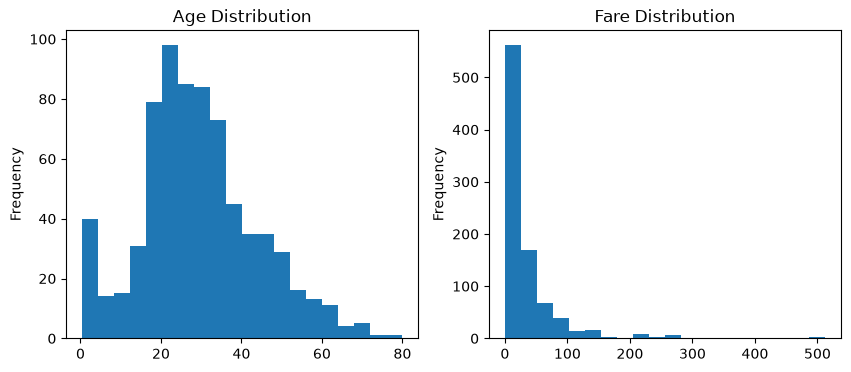

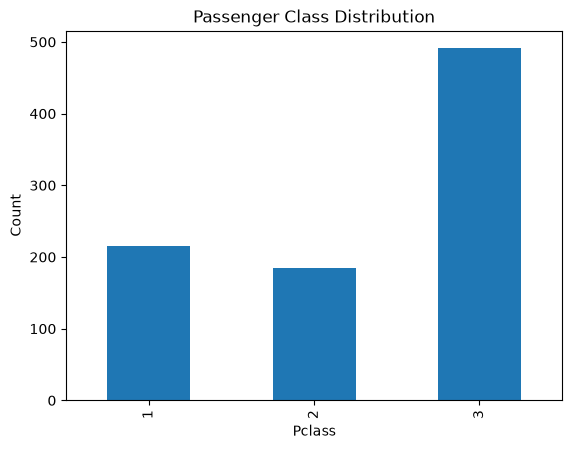

In [5]:
#STEP 3 - DISTRIBUTIONS

import matplotlib.pyplot as plt

# 2 Numeric columns (Histograms)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['Age'].plot(kind='hist', bins=20, ax=axes[0], title='Age Distribution')
df['Fare'].plot(kind='hist', bins=20, ax=axes[1], title='Fare Distribution')
plt.show()

# 1 Categorical column (Bar chart)
df['Pclass'].value_counts().sort_index().plot(kind='bar', title='Passenger Class Distribution')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.show()

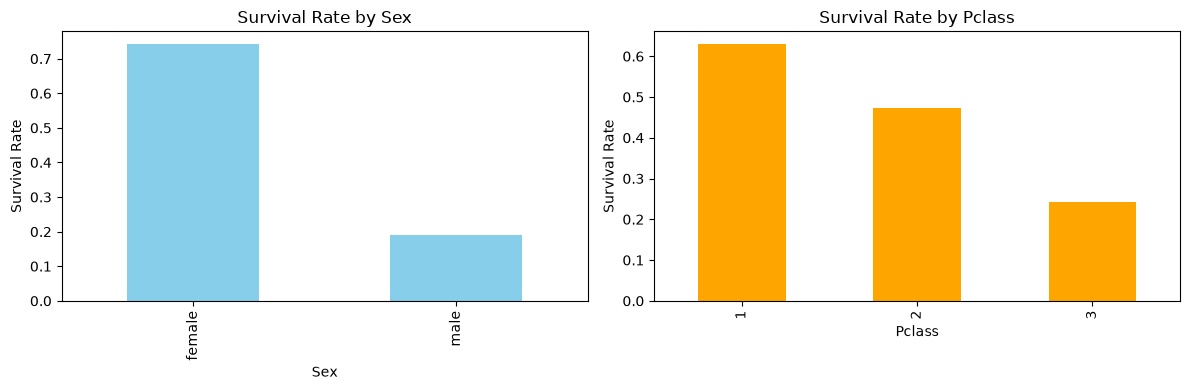

In [7]:
#STEP 4 - RELATIONSHIPS

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Visualization 1: Sex vs Survived
df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')

# Visualization 2: Pclass vs Survived
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Survival Rate by Pclass')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

In [11]:
#STEP 5 - CLEANING

# Drop duplicates (if any)
df_clean = df.drop_duplicates().copy()

# Treat missing values: Fill Age with median, Embarked with mode, drop Cabin & unused columns
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
df_clean = df_clean.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'])

# Encode categorical variables using Pandas
df_clean = pd.get_dummies(df_clean, columns=['Sex', 'Embarked'], drop_first=True, dtype=float)

# Scale numeric features using Standardization (Z-score scaling) via Pandas
for col in ['Age', 'Fare']:
    df_clean[col] = (df_clean[col] - df_clean[col].mean()) / df_clean[col].std()

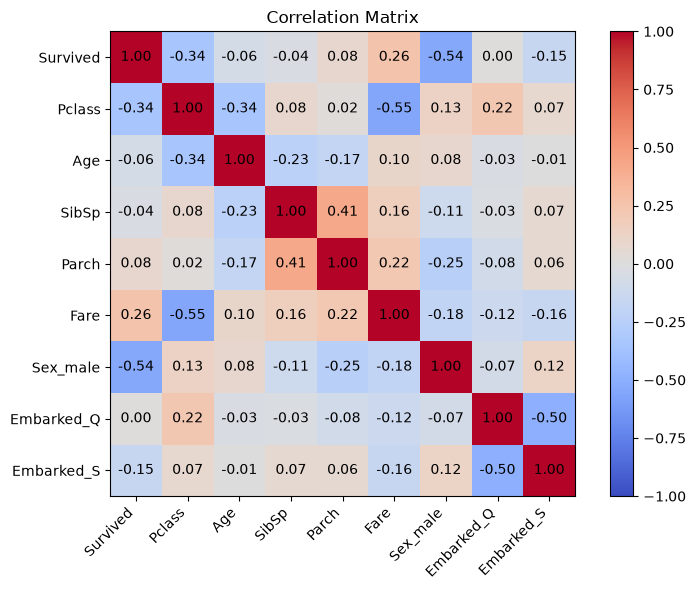

Top 3 predictors of survival:
Sex_male    0.543351
Pclass      0.338481
Fare        0.257307
Name: Survived, dtype: float64


In [13]:

#STEP 6 - CORRELATION AND TOP PREDICTORS
import matplotlib.pyplot as plt

# 1. Compute the correlation matrix
corr_matrix = df_clean.corr()

# 2. Plot the heatmap using Matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

# Add row and column labels
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Correlation Matrix')

# Annotate numerical values inside each cell
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

# 3. Identify top 3 non-target features most correlated with survival
top_3_predictors = corr_matrix['Survived'].abs().sort_values(ascending=False)[1:4]
print("Top 3 predictors of survival:")
print(top_3_predictors)

In [14]:
#STEP 7 - SAVE THE CLEANED DATASET
#Save the cleaned DataFrame to a CSV file without including the index column
df_clean.to_csv('titanic_cleaned.csv', index=False)

print("¡Archivo 'titanic_cleaned.csv' guardado exitosamente!")

¡Archivo 'titanic_cleaned.csv' guardado exitosamente!
